# Semana 2 — Leitura dos áudios e dos labels

**TCC — Detecção de Voz Sintética** · Eduardo Zanella Bento

Objetivo desta semana (cronograma): *notebook lendo os áudios e metadados, com uma
tabela contendo arquivo, caminho, label e classe binária.*

Etapas:
1. Carregar a configuração central (`config.yaml`)
2. Inspecionar o arquivo de chaves cru
3. Montar a tabela de labels
4. Olhar a distribuição de classes (justifica `class_weights`)
5. Abrir UM áudio para confirmar sample rate e duração
6. Salvar a tabela em CSV

In [1]:
import sys, yaml
from pathlib import Path
import pandas as pd

# Permite importar o pacote src/ de dentro da pasta notebooks/
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from data.carregar_dados import inspecionar_arquivo, carregar_labels, resumo_distribuicao

cfg = yaml.safe_load(open(RAIZ / "config" / "config.yaml", encoding="utf-8"))
caminho_chaves = RAIZ / cfg["dataset"]["caminho_chaves"]
caminho_audios = RAIZ / cfg["dataset"]["caminho_audios"]
print("Chaves:", caminho_chaves)
print("Áudios:", caminho_audios)

Chaves: C:\dev\Tcc_Deepfake\data\raw\keys\LA\CM\trial_metadata.txt
Áudios: C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_eval\flac


## 1) Inspeção do arquivo bruto

**Sempre** olhe o dado cru antes de parsear. Isto confirma o separador e quantas
colunas o arquivo tem na sua versão.

In [2]:
inspecionar_arquivo(str(caminho_chaves))

Arquivo: C:\dev\Tcc_Deepfake\data\raw\keys\LA\CM\trial_metadata.txt
  linha 0: 8 colunas -> ['LA_0009', 'LA_E_9332881', 'alaw', 'ita_tx', 'A07', 'spoof', 'notrim', 'eval']
  linha 1: 8 colunas -> ['LA_0009', 'LA_E_6866159', 'alaw', 'ita_tx', 'A07', 'spoof', 'notrim', 'eval']
  linha 2: 8 colunas -> ['LA_0009', 'LA_E_5464494', 'alaw', 'sin_tx', 'A07', 'spoof', 'notrim', 'eval']
  linha 3: 8 colunas -> ['LA_0009', 'LA_E_4759417', 'alaw', 'sin_tx', 'A07', 'spoof', 'notrim', 'eval']
  linha 4: 8 colunas -> ['LA_0009', 'LA_E_2667748', 'alaw', 'loc_tx', 'A07', 'spoof', 'notrim', 'eval']


## 2) Montar a tabela de labels

`classe_binaria`: **0 = bonafide (real)**, **1 = spoof (sintético)**.

In [3]:
df = carregar_labels(str(caminho_chaves), str(caminho_audios))
print("Linhas:", len(df))
df.head(10)

Linhas: 181566


,arquivo,caminho,ataque,label,classe_binaria
0,LA_E_9332881,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
1,LA_E_6866159,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
2,LA_E_5464494,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
3,LA_E_4759417,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
4,LA_E_2667748,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
5,LA_E_8589971,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
6,LA_E_1911364,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
7,LA_E_5298786,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
8,LA_E_2042719,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1
9,LA_E_5449181,C:\dev\Tcc_Deepfake\data\raw\ASVspoof2021_LA_e...,A07,spoof,1


## 3) Distribuição de classes

O desbalanceamento que aparece aqui é a justificativa técnica do `class_weights`
na metodologia (pergunta de banca certeira).

In [4]:
resumo_distribuicao(df)


Total de áudios: 181566
  spoof    :  163114  (89.8%)
  bonafide :   18452  (10.2%)
  Razão spoof:bonafide = 8.8 : 1


## 4) Abrir UM áudio (confirmar sample rate e duração)

Aqui a gente confirma, na prática, o que está no `config.yaml`: o ASVspoof é 16 kHz.

Arquivo : LA_E_9332881.flac
Sample rate: 16000 Hz
Duração : 3.28 s  (52480 amostras)


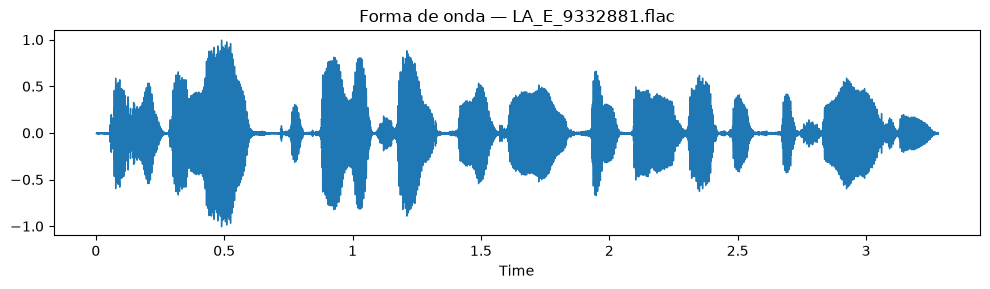

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Pega o primeiro áudio que realmente existe no disco
exemplo = None
for caminho in df["caminho"]:
    if Path(caminho).exists():
        exemplo = caminho
        break

if exemplo is None:
    print("Nenhum .flac encontrado ainda. Baixe e descompacte o dataset em data/raw/.")
else:
    y, sr = librosa.load(exemplo, sr=None)  # sr=None preserva a taxa original
    print(f"Arquivo : {Path(exemplo).name}")
    print(f"Sample rate: {sr} Hz")
    print(f"Duração : {len(y)/sr:.2f} s  ({len(y)} amostras)")

    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Forma de onda — {Path(exemplo).name}")
    plt.tight_layout(); plt.show()

## 5) Salvar a tabela

Esta tabela é o insumo das próximas semanas (pré-processamento e extração de features).

In [6]:
saida = RAIZ / "data" / "processed" / "labels.csv"
saida.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(saida, index=False)
print("Salvo em:", saida)

Salvo em: C:\dev\Tcc_Deepfake\data\processed\labels.csv
